In [1]:
import pandas as pd
import numpy as np
import os
df = pd.read_csv("data/PSX_Oil_Sector_Combined_2016_2026(Sheet1).csv")
print(df.shape)
display(df.head())

(40347, 10)


,Company,Symbol,Date,Price,Open,High,Low,Vol.,Change %,Country
0,Attock Petroleum,APL,2016-01-01 00:00:00,332.34,333.34,333.34,332.01,0.75K,-0.0131,Pakistan
1,Attock Petroleum,APL,2016-01-05 00:00:00,330.61,330.00,333.33,328.67,6.15K,-0.0052,Pakistan
2,Attock Petroleum,APL,2016-01-06 00:00:00,328.00,330.00,330.00,326.00,3.75K,-0.0079,Pakistan
3,Attock Petroleum,APL,2016-01-07 00:00:00,324.00,326.67,326.67,323.33,7.95K,-0.0122,Pakistan
4,Attock Petroleum,APL,2016-01-08 00:00:00,320.01,322.00,322.00,320.01,2.85K,-0.0123,Pakistan


# **Data Preprocessing**

In [2]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler

# 1. Load data from CSV
csv_file = 'data/PSX_Oil_Sector_Combined_2016_2026(Sheet1).csv'
if not os.path.exists(csv_file):
    print(f"❌ Error: {csv_file} not found.")
    exit()

df = pd.read_csv(csv_file)
df['Date'] = pd.to_datetime(df['Date'])

# --- 1.5 PRE-PROCESSING: Clean Volume Column ---
# Rename 'Vol.' to 'Volume'
if 'Vol.' in df.columns:
    df.rename(columns={'Vol.': 'Volume'}, inplace=True)

# Convert strings like '0.75K' or '1.3M' to actual numbers
def convert_volume(val):
    if pd.isna(val):
        return 0.0
    val_str = str(val).strip().upper()
    if val_str.endswith('K'):
        return float(val_str[:-1]) * 1000
    elif val_str.endswith('M'):
        return float(val_str[:-1]) * 1000000
    elif val_str.endswith('B'):
        return float(val_str[:-1]) * 1000000000
    else:
        try:
            return float(val_str.replace(',', ''))
        except ValueError:
            return 0.0

if 'Volume' in df.columns:
    df['Volume'] = df['Volume'].apply(convert_volume)

print(f"Loaded {len(df)} rows. Starting Feature Engineering...")

# 2. Process each company separately to avoid mixing data
all_companies_processed = []

for symbol in df['Symbol'].unique():
    # Get data for one company and sort it by date
    comp_df = df[df['Symbol'] == symbol].sort_values('Date').copy()
    
    # --- A. LAG FEATURES ---
    # We use .bfill() so the first few days just copy the earliest known price instead of being NaN
    comp_df['Price_Yesterday'] = comp_df['Price'].shift(1).bfill()
    comp_df['Price_5_Days_Ago'] = comp_df['Price'].shift(5).bfill()
    
    # --- B. MOVING AVERAGES ---
    # min_periods=1 ensures calculation even on day 1
    comp_df['MA7'] = comp_df['Price'].rolling(window=7, min_periods=1).mean()
    comp_df['MA30'] = comp_df['Price'].rolling(window=30, min_periods=1).mean()
    
    # --- C. DAILY RETURNS ---
    # comp_df['Daily_Return'] = comp_df['Price'].pct_change().fillna(0)
    
    # --- D. TIME FEATURES ---
    comp_df['Day_Of_Week'] = comp_df['Date'].dt.dayofweek
    comp_df['Month'] = comp_df['Date'].dt.month
    
    # --- E. THE TARGET COLUMN ---
    comp_df['Target_Next_Day_Price'] = comp_df['Price'].shift(-1)
    
    all_companies_processed.append(comp_df)

# 3. Combine all companies back together
final_df = pd.concat(all_companies_processed)

# --- F. DATA CLEANING FOR ML ---
cols_to_drop = ['Country', 'Company', 'Date']
final_df = final_df.drop(columns=cols_to_drop)

# --- G. ONE-HOT ENCODING (OHE) ---
print("Applying One-Hot Encoding to Symbols...")
final_df = pd.get_dummies(final_df, columns=['Symbol'], prefix='Symbol')

# --- H. FEATURE SCALING ---
print("Scaling numeric features...")
scaler = StandardScaler()

# List of columns to scale (Updated to 'Volume' instead of 'Vol.')
features_to_scale = [
    'Price', 'Open', 'High', 'Low', 'Volume', 
    'Price_Yesterday', 'Price_5_Days_Ago', 
    'MA7', 'MA30', 'Change %', 'Day_Of_Week', 'Month'
]

final_df[features_to_scale] = scaler.fit_transform(final_df[features_to_scale])

# 4. Final Cleanup
# We only drop rows where the *Target* is empty. 
final_df = final_df.dropna(subset=['Target_Next_Day_Price'])

print(f"Feature Engineering, Encoding & Scaling complete! Final shape: {final_df.shape}")
print(f"New columns: {final_df.columns.tolist()[:]}")

# 5. Save this as a NEW CSV file called 'training_data.csv'
final_df.to_csv('data/training_data.csv', index=False)

print("✅ Phase 3 Finalized! Data is scaled and encoded in training_data.csv")


Loaded 40347 rows. Starting Feature Engineering...
Applying One-Hot Encoding to Symbols...
Scaling numeric features...
Feature Engineering, Encoding & Scaling complete! Final shape: (40330, 30)
New columns: ['Price', 'Open', 'High', 'Low', 'Volume', 'Change %', 'Price_Yesterday', 'Price_5_Days_Ago', 'MA7', 'MA30', 'Day_Of_Week', 'Month', 'Target_Next_Day_Price', 'Symbol_APL', 'Symbol_ATRL', 'Symbol_BLPL', 'Symbol_CNERGY', 'Symbol_HASCOL', 'Symbol_HTL', 'Symbol_MARI', 'Symbol_NRL', 'Symbol_OBOY', 'Symbol_OGDC', 'Symbol_POL', 'Symbol_PPL', 'Symbol_PRL', 'Symbol_PSO', 'Symbol_SNGP', 'Symbol_SSGC', 'Symbol_WAFI']
✅ Phase 3 Finalized! Data is scaled and encoded in training_data.csv


In [3]:
print(final_df.shape)
pd.set_option('display.max_columns', None)
display(final_df.head())

(40330, 30)


,Price,Open,High,Low,Volume,Change %,Price_Yesterday,Price_5_Days_Ago,MA7,MA30,Day_Of_Week,Month,Target_Next_Day_Price,Symbol_APL,Symbol_ATRL,Symbol_BLPL,Symbol_CNERGY,Symbol_HASCOL,Symbol_HTL,Symbol_MARI,Symbol_NRL,Symbol_OBOY,Symbol_OGDC,Symbol_POL,Symbol_PPL,Symbol_PRL,Symbol_PSO,Symbol_SNGP,Symbol_SSGC,Symbol_WAFI
0,0.808036,0.812886,0.783043,0.837252,-0.375507,-0.453278,0.808517,0.810262,0.812103,0.824198,1.320771,-1.538843,330.61,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,0.799872,0.797108,0.782997,0.821128,-0.374869,-0.191219,0.808517,0.810262,0.808004,0.820052,-0.712054,-1.538843,328.00,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,0.787555,0.797108,0.767606,0.808238,-0.375153,-0.280784,0.800350,0.810262,0.802515,0.814499,-0.034446,-1.538843,324.00,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,0.768680,0.781376,0.752215,0.795349,-0.374657,-0.423423,0.788030,0.810262,0.795032,0.806929,0.643162,-1.538843,320.01,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,0.749851,0.759314,0.730631,0.779322,-0.375259,-0.426740,0.769149,0.810262,0.786761,0.798562,1.320771,-1.538843,319.28,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


# Separate features (X) and target (Y)

In [4]:
# X contains everything EXCEPT the target column
X = final_df.drop(columns=['Target_Next_Day_Price'])

# Y contains ONLY the target column
Y = final_df['Target_Next_Day_Price']

print(f"X shape (Features): {X.shape}")
print(f"Y shape (Target): {Y.shape}")

X shape (Features): (40330, 29)
Y shape (Target): (40330,)


--- 📊 Technical Feature Correlation Values ---
Price               0.996917
High                0.996587
Low                 0.996278
Open                0.995957
Price_Yesterday     0.993692
MA7                 0.992537
Price_5_Days_Ago    0.984783
MA30                0.977291
Day_Of_Week         0.189595
Change %            0.022634
Month              -0.003910
Volume             -0.159326
dtype: float64

--- 🛠️ Automated Cleaning ---
Dropping 2 weak features: ['Change %', 'Month']
✅ Weak features removed.

Final feature count: 27
Remaining technical features: ['Price', 'Open', 'High', 'Low', 'Volume', 'Price_Yesterday', 'Price_5_Days_Ago', 'MA7', 'MA30', 'Day_Of_Week']


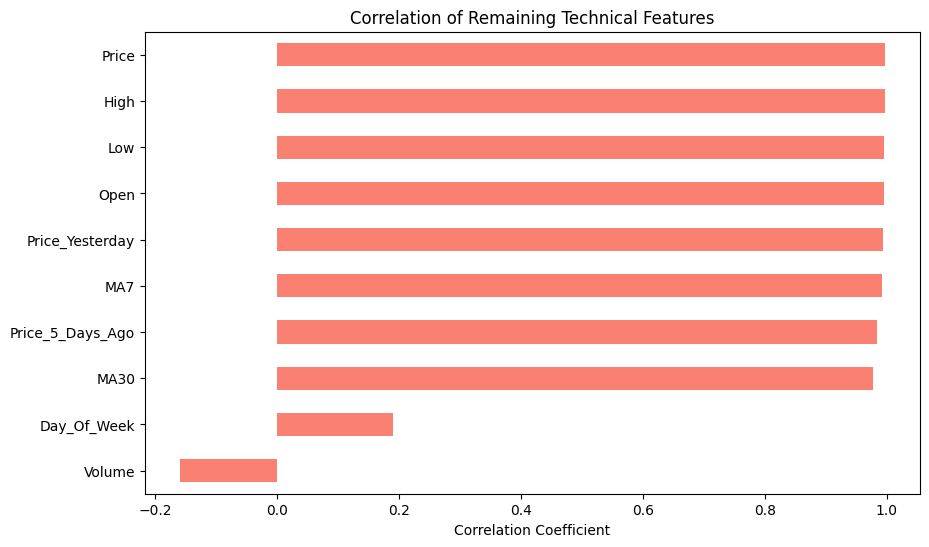

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate Correlation with Target
target_corr = X.corrwith(Y)

# 2. Separate technical features from Symbol features for analysis
# We exclude 'Symbol_' columns from the auto-drop logic to keep company identification
technical_features = [col for col in X.columns if not col.startswith('Symbol_')]
symbol_features = [col for col in X.columns if col.startswith('Symbol_')]

print("--- 📊 Technical Feature Correlation Values ---")
print(target_corr[technical_features].sort_values(ascending=False))

# 3. Automated Feature Selection
# Threshold: Drop features with less than 5% (0.05) correlation
threshold = 0.05
features_to_drop = [feat for feat in technical_features if abs(target_corr[feat]) < threshold]

print(f"\n--- 🛠️ Automated Cleaning ---")
if features_to_drop:
    print(f"Dropping {len(features_to_drop)} weak features: {features_to_drop}")
    X = X.drop(columns=features_to_drop)
    print("✅ Weak features removed.")
else:
    print("✨ All technical features meet the threshold. Nothing dropped.")

# 4. Final Feature Set Summary
print(f"\nFinal feature count: {X.shape[1]}")
print(f"Remaining technical features: {[f for f in X.columns if f not in symbol_features]}")

# 5. Visualizing the final correlation of remaining technical features
plt.figure(figsize=(10, 6))
target_corr[technical_features].drop(labels=features_to_drop, errors='ignore').sort_values().plot(kind='barh', color='salmon')
plt.title("Correlation of Remaining Technical Features")
plt.xlabel("Correlation Coefficient")
plt.savefig("results/correlation of features.png")
plt.show()

In [6]:
X

,Price,Open,High,Low,Volume,Price_Yesterday,Price_5_Days_Ago,MA7,MA30,Day_Of_Week,Symbol_APL,Symbol_ATRL,Symbol_BLPL,Symbol_CNERGY,Symbol_HASCOL,Symbol_HTL,Symbol_MARI,Symbol_NRL,Symbol_OBOY,Symbol_OGDC,Symbol_POL,Symbol_PPL,Symbol_PRL,Symbol_PSO,Symbol_SNGP,Symbol_SSGC,Symbol_WAFI
0,0.808036,0.812886,0.783043,0.837252,-0.375507,0.808517,0.810262,0.812103,0.824198,1.320771,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,0.799872,0.797108,0.782997,0.821128,-0.374869,0.808517,0.810262,0.808004,0.820052,-0.712054,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,0.787555,0.797108,0.767606,0.808238,-0.375153,0.800350,0.810262,0.802515,0.814499,-0.034446,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,0.768680,0.781376,0.752215,0.795349,-0.374657,0.788030,0.810262,0.795032,0.806929,0.643162,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,0.749851,0.759314,0.730631,0.779322,-0.375259,0.769149,0.810262,0.786761,0.798562,1.320771,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40341,0.073529,0.083289,0.069237,0.079291,-0.373462,0.079363,0.068574,0.075534,0.142748,-1.389662,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
40342,0.073765,0.069636,0.064939,0.074463,-0.373798,0.073793,0.070701,0.075453,0.135392,-0.712054,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
40343,0.157149,0.112106,0.140923,0.108255,-0.348174,0.074029,0.094989,0.088335,0.131469,-0.034446,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
40344,0.175412,0.154623,0.166759,0.127565,-0.364870,0.157437,0.065314,0.103532,0.127896,0.643162,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True


In [7]:
from sklearn.model_selection import train_test_split

# Split data: 80% for training (the past) and 20% for testing (the future)
# shuffle=False ensures chronological order is kept intact!
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=False)

print(f"Training data (X) shape: {X_train.shape}")
print(f"Testing data (X) shape: {X_test.shape}")
print(f"Training target (Y) shape: {Y_train.shape}")
print(f"Testing target (Y) shape: {Y_test.shape}")

Training data (X) shape: (32264, 27)
Testing data (X) shape: (8066, 27)
Training target (Y) shape: (32264,)
Testing target (Y) shape: (8066,)


# **Model Training**

In [8]:
import pandas as pd
import numpy as np
import warnings
import os
import joblib  # Standard for saving Scikit-Learn models
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# Scikit-Learn Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

warnings.filterwarnings('ignore') # Hides annoying warnings during training

# Attempt to load external boosting libraries gracefully
try:
    from xgboost import XGBRegressor
    has_xgb = True
except ImportError:
    has_xgb = False

try:
    from lightgbm import LGBMRegressor
    has_lgbm = True
except ImportError:
    has_lgbm = False

try:
    from catboost import CatBoostRegressor
    has_catboost = True
except ImportError:
    has_catboost = False

# 1. Define all the models in a dictionary
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Elastic Net": ElasticNet(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting (Sklearn)": GradientBoostingRegressor(random_state=42),
    "SVR (Support Vector)": SVR(),
    "K-Nearest Neighbors": KNeighborsRegressor(),
    "AdaBoost": AdaBoostRegressor(random_state=42)
}

if has_xgb:
    models["XGBoost"] = XGBRegressor(random_state=42)
if has_lgbm:
    models["LightGBM"] = LGBMRegressor(random_state=42)
if has_catboost:
    models["CatBoost"] = CatBoostRegressor(verbose=0, random_state=42)


# 2. Train, Predict, Evaluate, and SAVE
results = {}
n = len(Y_test) 
p = X_test.shape[1] 

print("\n🚀 Training models & Saving to models/ folder...\n" + "="*60)

for name, model in models.items():
    try:
        # Train the model
        model.fit(X_train, Y_train)
        
        # 💾 SAVE THE MODEL IMMEDIATELY AFTER TRAINING
        # Cleaning the name to create a valid filename (removing spaces/brackets)
        filename = f"models/{name.replace(' ', '_').replace('(', '').replace(')', '').lower()}.pkl"
        joblib.dump(model, filename)
        
        # Predict on Test Data
        preds = model.predict(X_test)
        
        # Calculate Metrics
        mae = mean_absolute_error(Y_test, preds)
        mse = mean_squared_error(Y_test, preds)
        rmse = np.sqrt(mse)
        mape = mean_absolute_percentage_error(Y_test, preds)
        r2 = r2_score(Y_test, preds)
        adj_r2 = 1 - (1 - r2) * ((n - 1) / (n - p - 1))
        ssr = np.sum((Y_test - preds) ** 2)
        rse = np.sqrt(ssr / (n - p - 1))
        
        results[name] = {
            "MAE": mae, "MSE": mse, "RMSE": rmse, 
            "MAPE": mape, "R-Squared (R2)": r2, 
            "Adjusted R-Squared": adj_r2, "RSE": rse
        }
        print(f"✅ {name} trained and saved as {filename}")
        
    except Exception as e:
        print(f"❌ Error with {name}: {e}")

# 3. Create Leaderboard and Save CSV
results_df = pd.DataFrame(results).T.sort_values(by="RMSE")
print("\n🏆 Model Performance Leaderboard:")
display(results_df)

results_df.to_csv("results/model_performance.csv")
print("\n📁 Leaderboard saved to results/model_performance.csv")


🚀 Training models & Saving to models/ folder...
✅ Linear Regression trained and saved as models/linear_regression.pkl
✅ Ridge Regression trained and saved as models/ridge_regression.pkl
✅ Lasso Regression trained and saved as models/lasso_regression.pkl
✅ Elastic Net trained and saved as models/elastic_net.pkl
✅ Decision Tree trained and saved as models/decision_tree.pkl
✅ Random Forest trained and saved as models/random_forest.pkl
✅ Gradient Boosting (Sklearn) trained and saved as models/gradient_boosting_sklearn.pkl
✅ SVR (Support Vector) trained and saved as models/svr_support_vector.pkl
✅ K-Nearest Neighbors trained and saved as models/k-nearest_neighbors.pkl
✅ AdaBoost trained and saved as models/adaboost.pkl
✅ XGBoost trained and saved as models/xgboost.pkl
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001239 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.

,MAE,MSE,RMSE,MAPE,R-Squared (R2),Adjusted R-Squared,RSE
Lasso Regression,2.252958,14.265625,3.776986,0.035667,0.998664,0.998660,3.783559
LightGBM,2.087123,14.593659,3.820165,0.021598,0.998633,0.998629,3.826813
Gradient Boosting (Sklearn),2.299955,15.344138,3.917159,0.025490,0.998563,0.998558,3.923976
XGBoost,2.165760,15.494265,3.936275,0.023977,0.998549,0.998544,3.943125
Random Forest,2.191890,16.250679,4.031213,0.021255,0.998478,0.998473,4.038228
Ridge Regression,3.091121,17.916918,4.232838,0.073167,0.998322,0.998317,4.240204
Linear Regression,3.108597,18.003231,4.243021,0.073970,0.998314,0.998308,4.250405
CatBoost,2.645527,19.624564,4.429962,0.031840,0.998162,0.998156,4.437671
Decision Tree,3.140703,36.354041,6.029431,0.030714,0.996596,0.996584,6.039924
SVR (Support Vector),5.296604,54.646346,7.392317,0.174248,0.994883,0.994865,7.405181



📁 Leaderboard saved to results/model_performance.csv


In [ ]:
# Train vs Test Performance (Checking for Overfitting)
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

train_test_results = {}

for name, model in models.items():
    try:
        # Predict on both Train and Test data
        train_preds = model.predict(X_train)
        test_preds = model.predict(X_test)
        
        # Calculate R-Squared (Accuracy) for both
        train_r2 = r2_score(Y_train, train_preds)
        test_r2 = r2_score(Y_test, test_preds)
        
        # Calculate RMSE (Error) for both
        train_rmse = np.sqrt(mean_squared_error(Y_train, train_preds))
        test_rmse = np.sqrt(mean_squared_error(Y_test, test_preds))
        
        # Calculate Difference (Overfitting indicator)
        r2_diff = train_r2 - test_r2
        
        train_test_results[name] = {
            "Train R2": train_r2,
            "Test R2": test_r2,
            "R2 Difference": r2_diff,
            "Train RMSE": train_rmse,
            "Test RMSE": test_rmse
        }
    except:
        pass # Skip if a model fails

# Convert dictionary to DataFrame
train_test_df = pd.DataFrame(train_test_results).T

# Sort by highest Test Accuracy (Test R2)
train_test_df = train_test_df.sort_values(by="Test R2", ascending=False)

print("\n📊 Train vs Test Performance (Checking for Overfitting):")
display(train_test_df)
train_test_df.to_csv('results/train vs test performance.csv')


📊 Train vs Test Performance (Checking for Overfitting):


,Train R2,Test R2,R2 Difference,Train RMSE,Test RMSE
Lasso Regression,0.993508,0.998664,-0.005156,1.847253e+01,3.776986
LightGBM,0.989335,0.998633,-0.009298,2.367558e+01,3.820165
Gradient Boosting (Sklearn),0.999032,0.998563,0.000469,7.132774e+00,3.917159
XGBoost,0.996090,0.998549,-0.002459,1.433498e+01,3.936275
Random Forest,0.998647,0.998478,0.000169,8.432008e+00,4.031213
Ridge Regression,0.993644,0.998322,-0.004678,1.827793e+01,4.232838
Linear Regression,0.993646,0.998314,-0.004669,1.827547e+01,4.243021
CatBoost,0.993633,0.998162,-0.004530,1.829416e+01,4.429962
Decision Tree,1.000000,0.996596,0.003404,2.763294e-16,6.029431
SVR (Support Vector),0.694952,0.994883,-0.299930,1.266231e+02,7.392317


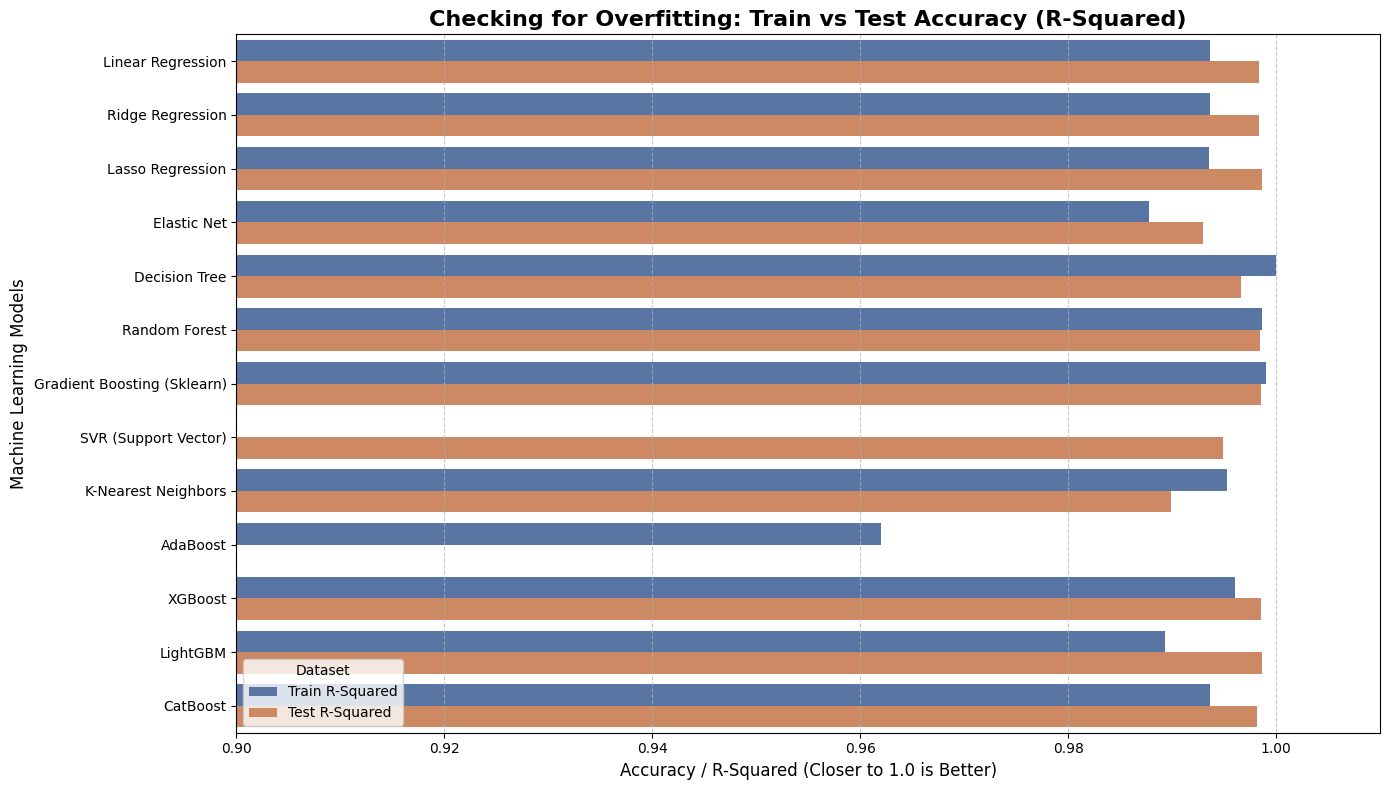

In [ ]:
# Train vs Test R-Squared Plot for all models
import matplotlib.pyplot as plt
import seaborn as sns

train_r2_scores = []
test_r2_scores = []
model_names_list = []

# 1. Calculate Train vs Test R-Squared for all models
for name, model in models.items():
    try:
        # Predict on both sets
        train_preds = model.predict(X_train)
        test_preds = model.predict(X_test)
        
        # Calculate R2
        train_r2 = r2_score(Y_train, train_preds)
        test_r2 = r2_score(Y_test, test_preds)
        
        train_r2_scores.append(train_r2)
        test_r2_scores.append(test_r2)
        model_names_list.append(name)
    except:
        pass # Skip if a model failed

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'Model': model_names_list,
    'Train R-Squared': train_r2_scores,
    'Test R-Squared': test_r2_scores
})

# Reshape data for Seaborn
plot_df_melted = plot_df.melt(id_vars='Model', var_name='Dataset', value_name='Accuracy (R-Squared)')


# ==========================================
# PLOT: Train vs Test Accuracy Bar Chart
# ==========================================
plt.figure(figsize=(14, 8))
sns.barplot(data=plot_df_melted, x='Accuracy (R-Squared)', y='Model', hue='Dataset', palette=['#4C72B0', '#DD8452'])

plt.title('Checking for Overfitting: Train vs Test Accuracy (R-Squared)', fontsize=16, fontweight='bold')
plt.xlabel('Accuracy / R-Squared (Closer to 1.0 is Better)', fontsize=12)
plt.ylabel('Machine Learning Models', fontsize=12)
plt.xlim(0.9, 1.01) # We zoom in between 0.9 and 1.0 because your models are highly accurate
plt.legend(title='Dataset', loc='lower left')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('results/train vs test performance.png')
plt.show()

# **Hyperparameter Tuning**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define the "Search Space"
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None] 
}

# Setup the tuner
rf_tuner = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=10, # Try 10 random combinations
    cv=3,      # 3-fold cross-validation
    scoring='neg_mean_squared_error',
    verbose=2,
    n_jobs=-1
)

# Run the tuning
rf_tuner.fit(X_train, Y_train)

# Get the best version of the model
best_rf = rf_tuner.best_estimator_
print(f"Best Parameters: {rf_tuner.best_params_}")

## **1. Linear Models (Regularization)**
The following code performs hyperparameter tuning for Ridge, Lasso, and Elastic Net regression using GridSearchCV. It calculates all the specific metrics you requested—including specialized calculations like Adjusted R-Squared and Residual Standard Error (RSE)

In [9]:
import pandas as pd
import numpy as np
import os
import pickle
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def calculate_metrics(model, X_train, X_test, Y_train, Y_test, name):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # Basic Metrics
    mae = mean_absolute_error(Y_test, test_pred)
    mse = mean_squared_error(Y_test, test_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((Y_test - test_pred) / Y_test)) * 100
    
    # R2 Metrics
    r2_train = r2_score(Y_train, train_pred)
    r2_test = r2_score(Y_test, test_pred)
    
    # Adjusted R-Squared
    n = len(Y_test)
    p = X_test.shape[1]
    adj_r2 = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)
    
    # Residual Standard Error (RSE)
    rss = np.sum((Y_test - test_pred) ** 2)
    rse = np.sqrt(rss / (n - p - 1))
    
    train_rmse = np.sqrt(mean_squared_error(Y_train, train_pred))
    
    return {
        'Model': name,
        'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape,
        'R-Squared (R2)': r2_test,
        'Adjusted R-Squared': adj_r2,
        'RSE': rse,
        'Train R2': r2_train,
        'Test R2': r2_test,
        'R2 Difference': abs(r2_train - r2_test),
        'Train RMSE': train_rmse,
        'Test RMSE': rmse
    }

results_list = []

# --- Ridge Tuning ---
ridge_grid = GridSearchCV(Ridge(), {'alpha': [0.01, 0.1, 1, 10, 100]}, cv=5)
ridge_grid.fit(X_train, Y_train)
results_list.append(calculate_metrics(ridge_grid.best_estimator_, X_train, X_test, Y_train, Y_test, 'Ridge Tuned'))
# Save Ridge Model
with open('models/tuned_ridge.pkl', 'wb') as f:
    pickle.dump(ridge_grid.best_estimator_, f)
# --- Lasso Tuning ---
lasso_grid = GridSearchCV(Lasso(), {'alpha': [0.001, 0.01, 0.1, 1, 10]}, cv=5)
lasso_grid.fit(X_train, Y_train)
results_list.append(calculate_metrics(lasso_grid.best_estimator_, X_train, X_test, Y_train, Y_test, 'Lasso Tuned'))
# Save Lasso Model
with open('models/tuned_lasso.pkl', 'wb') as f:
    pickle.dump(lasso_grid.best_estimator_, f)

# --- Elastic Net Tuning ---
elastic_grid = GridSearchCV(ElasticNet(), {'alpha': [0.01, 0.1, 1], 'l1_ratio': [0.2, 0.5, 0.8]}, cv=5)
elastic_grid.fit(X_train, Y_train)
results_list.append(calculate_metrics(elastic_grid.best_estimator_, X_train, X_test, Y_train, Y_test, 'Elastic Net Tuned'))
# Save Elastic Net Model
with open('models/tuned_elastic_net.pkl', 'wb') as f:
    pickle.dump(elastic_grid.best_estimator_, f)

# 3. Exporting Results
df_results = pd.DataFrame(results_list)
display(results_list)
df_results.to_csv('results/1-linear_tuned_model_performance.csv', index=False)

[{'Model': 'Ridge Tuned',
  'MAE': 2.8642015120766566,
  'MSE': 18.51052411031813,
  'RMSE': np.float64(4.302385862555581),
  'MAPE': np.float64(5.7904282836815915),
  'R-Squared (R2)': 0.9982665741042955,
  'Adjusted R-Squared': 0.9982607514495078,
  'RSE': np.float64(4.309872928762907),
  'Train R2': 0.9932252540684839,
  'Test R2': 0.9982665741042955,
  'R2 Difference': 0.005041320035811592,
  'Train RMSE': np.float64(18.87017032041273),
  'Test RMSE': np.float64(4.302385862555581)},
 {'Model': 'Lasso Tuned',
  'MAE': 2.0619884736494707,
  'MSE': 13.783565986134956,
  'RMSE': np.float64(3.7126225213634307),
  'MAPE': np.float64(2.4973334892343346),
  'R-Squared (R2)': 0.9987092321063886,
  'Adjusted R-Squared': 0.9987048963595452,
  'RSE': np.float64(3.71908327395705),
  'Train R2': 0.9935235597813333,
  'Test R2': 0.9987092321063886,
  'R2 Difference': 0.0051856723250552905,
  'Train RMSE': np.float64(18.450047738981247),
  'Test RMSE': np.float64(3.7126225213634307)},
 {'Model': '

## 2. Tree-Based Models (Single & Ensembles)
Hyperparameter tuning for Decision Tree and Random Forest models using GridSearchCV.

Since tree ensembles are computationally heavier than linear models, I have included a subset of common parameters (like max_depth and min_samples_split) to balance tuning quality and execution time.

In [10]:
import pandas as pd
import numpy as np
import os
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Setup and Directory
os.makedirs('results', exist_ok=True)

# Replace with your actual dataframe loading
# X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def calculate_all_metrics(model, X_train, X_test, Y_train, Y_test, name):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # Error Metrics
    mae = mean_absolute_error(Y_test, test_pred)
    mse = mean_squared_error(Y_test, test_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((Y_test - test_pred) / Y_test)) * 100
    
    # R2 & Variance Metrics
    r2_train = r2_score(Y_train, train_pred)
    r2_test = r2_score(Y_test, test_pred)
    
    # Adjusted R-Squared
    n = len(Y_test)
    p = X_test.shape[1]
    adj_r2 = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)
    
    # Residual Standard Error (RSE)
    rss = np.sum((Y_test - test_pred) ** 2)
    rse = np.sqrt(rss / (n - p - 1))
    
    train_rmse = np.sqrt(mean_squared_error(Y_train, train_pred))
    
    return {
        'Model': name,
        'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape,
        'R-Squared (R2)': r2_test,
        'Adjusted R-Squared': adj_r2,
        'RSE': rse,
        'Train R2': r2_train,
        'Test R2': r2_test,
        'R2 Difference': abs(r2_train - r2_test),
        'Train RMSE': train_rmse,
        'Test RMSE': rmse
    }

tree_results = []

# --- 1. Decision Tree Tuning ---
# Focus: Controlling tree growth to prevent overfitting
dt_params = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}
dt_grid = GridSearchCV(DecisionTreeRegressor(random_state=42), dt_params, cv=5)
dt_grid.fit(X_train, Y_train)
tree_results.append(calculate_all_metrics(dt_grid.best_estimator_, X_train, X_test, Y_train, Y_test, 'Decision Tree Tuned'))
# save decision tree model
with open('models/tuned_decision_tree.pkl', 'wb') as f:
    pickle.dump(dt_grid.best_estimator_, f)

# --- 2. Random Forest Tuning ---
# Focus: Number of trees and feature sampling
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=3, n_jobs=-1)
rf_grid.fit(X_train, Y_train)
tree_results.append(calculate_all_metrics(rf_grid.best_estimator_, X_train, X_test, Y_train, Y_test, 'Random Forest Tuned'))
# save rf model
# Save Elastic Net Model
with open('models/tuned_rf.pkl', 'wb') as f:
    pickle.dump(rf_grid.best_estimator_, f)
# 3. Save to CSV
df_trees = pd.DataFrame(tree_results)
display(tree_results)
df_trees.to_csv('results/2-tree_tuned_model_performance.csv', index=False)

[{'Model': 'Decision Tree Tuned',
  'MAE': 2.25213933559343,
  'MSE': 16.918840823626624,
  'RMSE': np.float64(4.113251855117387),
  'MAPE': np.float64(2.177837532099757),
  'R-Squared (R2)': 0.9984156279620073,
  'Adjusted R-Squared': 0.9984103059857663,
  'RSE': np.float64(4.120409787936638),
  'Train R2': 0.9964394807010352,
  'Test R2': 0.9984156279620073,
  'R2 Difference': 0.001976147260972172,
  'Train RMSE': np.float64(13.679996482947368),
  'Test RMSE': np.float64(4.113251855117387)},
 {'Model': 'Random Forest Tuned',
  'MAE': 2.2005213413328724,
  'MSE': 16.664354943318347,
  'RMSE': np.float64(4.082199767688782),
  'MAPE': np.float64(2.2117412338901703),
  'R-Squared (R2)': 0.9984394594004037,
  'Adjusted R-Squared': 0.9984342174750256,
  'RSE': np.float64(4.089303663273374),
  'Train R2': 0.9981415178532935,
  'Test R2': 0.9984394594004037,
  'R2 Difference': 0.00029794154711015874,
  'Train RMSE': np.float64(9.883448654439295),
  'Test RMSE': np.float64(4.082199767688782)}

# 3. Distance & Kernel-Based Models:
Hyperparameter tuning for K-Nearest Neighbors (KNN) and Support Vector Regression (SVR).

In [ ]:
import pandas as pd
import numpy as np
import os
import pickle
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Setup and Directory
os.makedirs('results', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Note: X_train, X_test, Y_train, Y_test are assumed to be pre-defined

def calculate_all_metrics(model, X_train, X_test, Y_train, Y_test, name):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # Error Metrics
    mae = mean_absolute_error(Y_test, test_pred)
    mse = mean_squared_error(Y_test, test_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((Y_test - test_pred) / Y_test)) * 100
    
    # Fit Metrics
    r2_train = r2_score(Y_train, train_pred)
    r2_test = r2_score(Y_test, test_pred)
    
    # Adjusted R-Squared
    n = len(Y_test)
    p = X_test.shape[1]
    adj_r2 = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)
    
    # Residual Standard Error (RSE)
    rss = np.sum((Y_test - test_pred) ** 2)
    rse = np.sqrt(rss / (n - p - 1))
    
    return {
        'Model': name,
        'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape,
        'R-Squared (R2)': r2_test,
        'Adjusted R-Squared': adj_r2,
        'RSE': rse,
        'Train R2': r2_train,
        'Test R2': r2_test,
        'R2 Difference': abs(r2_train - r2_test),
        'Train RMSE': np.sqrt(mean_squared_error(Y_train, train_pred)),
        'Test RMSE': rmse
    }

kernel_results = []

# --- 1. KNN Tuning (Streamlined) ---
# Faster grid: removed 'minkowski' and used discrete neighbor counts
knn_params = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn_random = RandomizedSearchCV(
    KNeighborsRegressor(), 
    param_distributions=knn_params, 
    n_iter=8,  # Lowered iterations
    cv=3,       # 3-fold CV is much faster than 5-fold
    random_state=42,
    n_jobs=-1
)
knn_random.fit(X_train, Y_train)
knn_best = knn_random.best_estimator_
kernel_results.append(calculate_all_metrics(knn_best, X_train, X_test, Y_train, Y_test, 'KNN Tuned'))
with open('models/tuned_knn.pkl', 'wb') as f:
    pickle.dump(knn_best, f)

# --- 2. SVR Tuning (Streamlined) ---
# Removed 'poly' kernel (slow) and focused on standard RBF ranges
svr_params = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto'],
    'epsilon': [0.1, 0.2]
}
svr_random = RandomizedSearchCV(
    SVR(kernel='rbf'), 
    param_distributions=svr_params, 
    n_iter=8, 
    cv=3, 
    random_state=42,
    n_jobs=-1
)

svr_random.fit(X_train, Y_train)
svr_best = svr_random.best_estimator_
kernel_results.append(calculate_all_metrics(svr_best, X_train, X_test, Y_train, Y_test, 'SVR Tuned'))

with open('models/tuned_svr.pkl', 'wb') as f:
    pickle.dump(svr_best, f)


# --- 3. Finalize and Save ---
df_kernel = pd.DataFrame(kernel_results)
df_kernel.to_csv('results/3-kernal_tuned_model_performance.csv', index=False)

print("Tuning complete. Results saved to 'results/' and models to 'models/'.")
print(df_kernel[['Model', 'R-Squared (R2)', 'MAE']])

Tuning complete. Results saved to 'results/' and models to 'models/'.
       Model  R-Squared (R2)       MAE
0  KNN Tuned        0.997366  2.863337
1  SVR Tuned        0.996932  4.882352


In [15]:
import pandas as pd
import glob
import os

# 1. Define the paths to your files
# You can list them manually:
file_list = [
    'results/1-linear_tuned_model_performance.csv',
    'results/2-tree_tuned_model_performance.csv',
    'results/3-kernal_tuned_model_performance.csv'
]

# 2. Use a list comprehension to read all CSVs into a list of DataFrames
df_list = [pd.read_csv(file) for file in file_list]

# 3. Combine them into one single DataFrame
combined_df = pd.concat(df_list, ignore_index=True)

combined_df.to_csv('results/all_models_performance.csv', index=False)

print("Successfully combined 3 files into 'results/all_models_performance.csv'")
display(combined_df)

Successfully combined 3 files into 'results/all_models_performance.csv'


,Model,MAE,MSE,RMSE,MAPE,R-Squared (R2),Adjusted R-Squared,RSE,Train R2,Test R2,R2 Difference,Train RMSE,Test RMSE
0,Ridge Tuned,2.864202,18.510524,4.302386,5.790428,0.998267,0.998261,4.309873,0.993225,0.998267,0.005041,18.870170,4.302386
1,Lasso Tuned,2.061988,13.783566,3.712623,2.497333,0.998709,0.998705,3.719083,0.993524,0.998709,0.005186,18.450048,3.712623
2,Elastic Net Tuned,2.463839,16.757331,4.093572,4.112097,0.998431,0.998425,4.100696,0.993286,0.998431,0.005145,18.785079,4.093572
3,Decision Tree Tuned,2.252139,16.918841,4.113252,2.177838,0.998416,0.998410,4.120410,0.996439,0.998416,0.001976,13.679996,4.113252
4,Random Forest Tuned,2.200521,16.664355,4.082200,2.211741,0.998439,0.998434,4.089304,0.998142,0.998439,0.000298,9.883449,4.082200
5,KNN Tuned,2.863337,28.122324,5.303049,3.368051,0.997366,0.997358,5.312277,1.000000,0.997366,0.002634,0.000000,5.303049
6,SVR Tuned,4.882352,32.757032,5.723376,12.234480,0.996932,0.996922,5.733336,0.993364,0.996932,0.003569,18.676198,5.723376


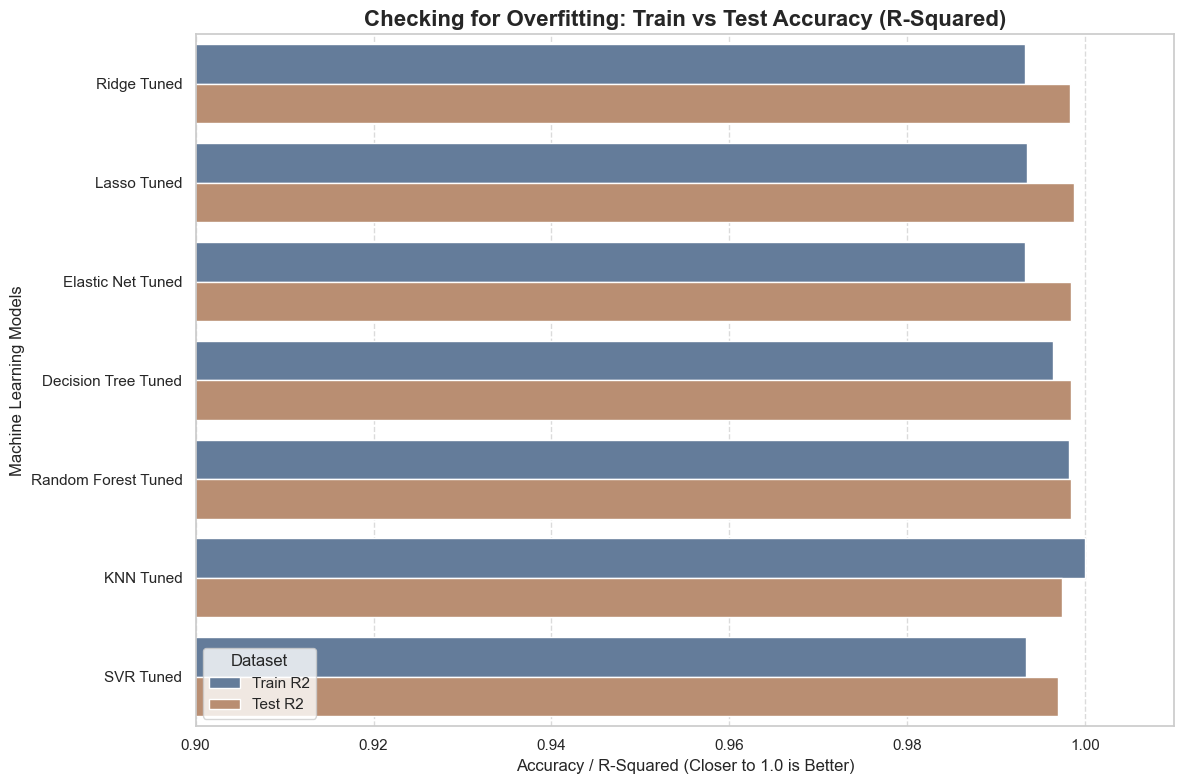

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the data (Using your example DF)
df = pd.read_csv('results/all_models_performance.csv')
# Select only the columns needed for the graph
df = df[['Model', 'Train R2', 'Test R2']]

# 2. "Melt" the dataframe to long-format for Seaborn
# This creates a 'Dataset' column and an 'R-Squared' column
df_melted = df.melt(id_vars='Model', 
                    value_vars=['Train R2', 'Test R2'], 
                    var_name='Dataset', 
                    value_name='R-Squared')

# 3. Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# 4. Create the horizontal bar plot
plot = sns.barplot(
    data=df_melted, 
    y='Model', 
    x='R-Squared', 
    hue='Dataset', 
    palette=['#5B7BA3', '#C58C66'] # Colors matching your image
)

# 5. Customize the chart (Matching the image specifics)
plt.title('Checking for Overfitting: Train vs Test Accuracy (R-Squared)', fontsize=16, fontweight='bold')
plt.xlabel('Accuracy / R-Squared (Closer to 1.0 is Better)', fontsize=12)
plt.ylabel('Machine Learning Models', fontsize=12)

# Set x-axis limits to zoom in on the differences (like in your image)
plt.xlim(0.90, 1.01) 

# Place legend at the bottom left
plt.legend(title='Dataset', loc='lower left')

# Add vertical gridlines for better readability
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('results/tuned-train vs test performance.png')
plt.show()

# PLOT : Random Forest Actual vs Predicted Line

Plot saved to results/tuned_rf_actual_vs_predicted.png


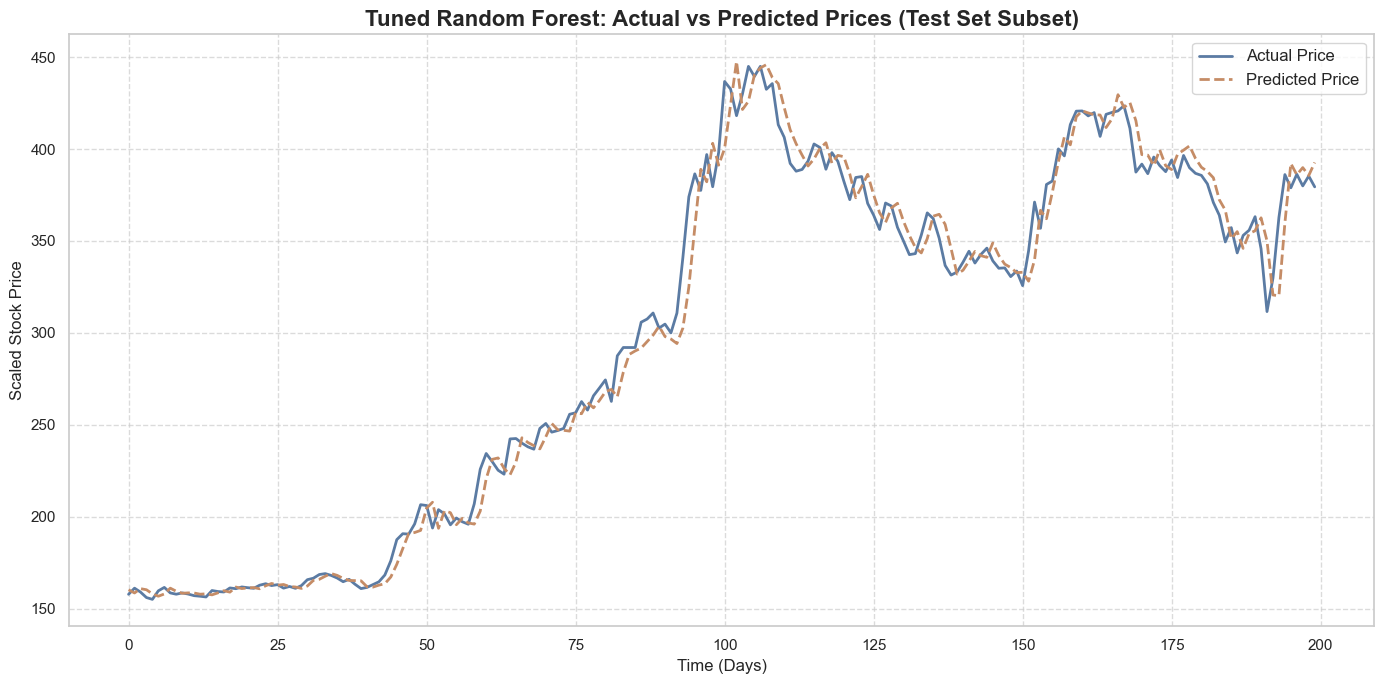

In [18]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('data/training_data.csv')

# 2. Extract X and Y just as in the notebook
# The notebook dropped 'Change %' and 'Month' along with 'Target_Next_Day_Price' for X
feature_cols = [
    'Price', 'Open', 'High', 'Low', 'Volume', 'Price_Yesterday', 
    'Price_5_Days_Ago', 'MA7', 'MA30', 'Day_Of_Week', 'Symbol_APL', 
    'Symbol_ATRL', 'Symbol_BLPL', 'Symbol_CNERGY', 'Symbol_HASCOL', 
    'Symbol_HTL', 'Symbol_MARI', 'Symbol_NRL', 'Symbol_OBOY', 
    'Symbol_OGDC', 'Symbol_POL', 'Symbol_PPL', 'Symbol_PRL', 
    'Symbol_PSO', 'Symbol_SNGP', 'Symbol_SSGC', 'Symbol_WAFI'
]
X = df[feature_cols]
Y = df['Target_Next_Day_Price']

# 3. Train Test Split (80/20, shuffle=False)
split_idx = int(len(df) * 0.8)
X_test = X.iloc[split_idx:]
Y_test = Y.iloc[split_idx:]

# 4. Load the tuned Random Forest model
model = joblib.load('models/tuned_rf.pkl')

# 5. Make predictions
predictions = model.predict(X_test)

# 6. Plot Actual vs Predicted Line Plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# To make the plot readable, we'll plot a subset of the test data (e.g., the last 100 or 200 days)
# Alternatively, we can plot the whole test set if it's not too crowded. Since test set is 8066 points,
# a line plot will be very dense. Let's plot the first 200 predictions to clearly show the trend.
subset_len = 200
plt.plot(Y_test.values[:subset_len], label='Actual Price', color='#5B7BA3', linewidth=2)
plt.plot(predictions[:subset_len], label='Predicted Price', color='#C58C66', linewidth=2, linestyle='--')

plt.title('Tuned Random Forest: Actual vs Predicted Prices (Test Set Subset)', fontsize=16, fontweight='bold')
plt.xlabel('Time (Days)', fontsize=12)
plt.ylabel('Scaled Stock Price', fontsize=12)
plt.legend(loc='best', fontsize=12)

# Add grid lines for readability
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot
plt.savefig('results/tuned_rf_actual_vs_predicted.png', dpi=300)
print("Plot saved to results/tuned_rf_actual_vs_predicted.png")


# **Prediction Funtion**

In [40]:
import joblib
import pandas as pd
import numpy as np

def predict_custom_value():
    # 1. Load the Model and Scaler
    # (You can change this to 'random_forest_oil_model.pkl' or 'xgboost_oil_model.pkl')
    model_path = 'xgboost_oil_model.pkl'
    model = joblib.load(model_path)
    scaler = joblib.load('oil_data_scaler.pkl')
    
    # 2. Define the exact symbols expected by the model
    all_symbols = [
        'APL', 'ATRL', 'BLPL', 'CNERGY', 'HASCOL', 'HTL', 'MARI', 'NRL', 
        'OBOY', 'OGDC', 'POL', 'PPL', 'PRL', 'PSO', 'SNGP', 'SSGC', 'WAFI'
    ]
    
    print(f"--- 🔮 Custom Prediction ({model_path}) ---")
    print(f"Available Symbols: {', '.join(all_symbols)}")
    
    try:
        # 3. Collect only the features present in your latest model
        inputs = {}
        inputs['Symbol'] = input("\n🏢 Enter Company Symbol: ").upper()
        inputs['Price'] = float(input("📈 Enter Today's Closing Price: "))
        inputs['Open'] = float(input("🔓 Enter Today's Open Price: "))
        inputs['High'] = float(input("🔼 Enter Today's High Price: "))
        inputs['Low'] = float(input("🔽 Enter Today's Low Price: "))
        inputs['Volume'] = float(input("📊 Enter Today's Volume: "))
        inputs['Price_Yesterday'] = float(input("⏪ Enter Yesterday's Price: "))
        inputs['Price_5_Days_Ago'] = float(input("📅 Enter Price 5 Days Ago: "))
        inputs['MA7'] = float(input("➖ Enter 7-Day Moving Average (MA7): "))
        inputs['MA30'] = float(input("〰️ Enter 30-Day Moving Average (MA30): "))
        inputs['Day_Of_Week'] = int(input("📅 Enter Day of Week (0=Mon, 4=Fri, 6=Sun): "))
        
        # 4. Handle Scaling
        # The scaler still expects 12 features (even though we dropped 2 from the model)
        # We fill 'Change %' and 'Month' with 0 as placeholders for the scaler
        features_for_scaler = [
            'Price', 'Open', 'High', 'Low', 'Volume', 
            'Price_Yesterday', 'Price_5_Days_Ago', 
            'MA7', 'MA30', 'Change %', 'Day_Of_Week', 'Month'
        ]
        
        temp_df = pd.DataFrame(0, index=[0], columns=features_for_scaler)
        for key in inputs:
            if key in features_for_scaler:
                temp_df[key] = inputs[key]
        
        # Scale all numeric features
        scaled_values = scaler.transform(temp_df)
        input_df = pd.DataFrame(scaled_values, columns=features_for_scaler)
        
        # 5. Handle One-Hot Encoding for the Symbol
        for sym in all_symbols:
            input_df[f'Symbol_{sym}'] = 1 if inputs['Symbol'] == sym else 0
            

        # 6. Reorder columns to match EXACTLY what the model expects
        final_features = input_df[model.feature_names_in_]
        
        # 7. Predict
        prediction = model.predict(final_features)[0]
        
        print(f"\n🎯 Result for {inputs['Symbol']}:")
        print(f"🚀 Predicted Tomorrow's Price: Rs. {prediction:.2f}")
        
    except ValueError:
        print("❌ Error: Please enter valid numbers for prices and volume.")
    except KeyError as e:
        print(f"❌ Error: Symbol '{inputs['Symbol']}' not recognized. Use one from the list above.")
    except Exception as e:
        print(f"❌ An error occurred: {e}")

# Run the prediction
predict_custom_value()


--- 🔮 Custom Prediction (xgboost_oil_model.pkl) ---
Available Symbols: APL, ATRL, BLPL, CNERGY, HASCOL, HTL, MARI, NRL, OBOY, OGDC, POL, PPL, PRL, PSO, SNGP, SSGC, WAFI



🎯 Result for APL:
🚀 Predicted Tomorrow's Price: Rs. 287.93
